# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

Data cleaning

In [2]:
chembl_df = pd.read_csv("chembl_200-500_10k.csv")
pubchem_df = pd.read_csv("pubchem_antibiotics.csv")

First clean up chembl_df

In [3]:
chembl_df.head()

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,SMILES,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."


In [4]:
chembl_df.duplicated().sum()

np.int64(0)

In [5]:
chembl_df.isna().sum()

ChEMBL ID                0
Name                  9818
Synonyms              9918
Type                     0
Max Phase             9925
Molecular Weight         0
Targets                407
Bioactivities          407
AlogP                   54
Polar Surface Area      54
HBA                     54
HBD                     54
#RO5 Violations         54
#Rotatable Bonds        54
Passes Ro3              54
QED Weighted            54
Aromatic Rings          54
Structure Type           0
Inorganic Flag           0
Heavy Atoms             54
Np Likeness Score       54
Molecular Formula        0
SMILES                   7
Inchi Key                7
Inchi                    7
Withdrawn Flag           0
Orphan                   0
Records Key            376
Records Name           376
dtype: int64

In [6]:
#Cleaning SMILES columns by dropping NaN values as this is the oclumn we care about
chembl_df_cleaned = chembl_df.dropna(subset=["SMILES"])
chembl_df_cleaned.isna().sum()

ChEMBL ID                0
Name                  9816
Synonyms              9912
Type                     0
Max Phase             9920
Molecular Weight         0
Targets                404
Bioactivities          404
AlogP                   47
Polar Surface Area      47
HBA                     47
HBD                     47
#RO5 Violations         47
#Rotatable Bonds        47
Passes Ro3              47
QED Weighted            47
Aromatic Rings          47
Structure Type           0
Inorganic Flag           0
Heavy Atoms             47
Np Likeness Score       47
Molecular Formula        0
SMILES                   0
Inchi Key                0
Inchi                    0
Withdrawn Flag           0
Orphan                   0
Records Key            374
Records Name           374
dtype: int64

In [7]:
# standardizing column names
chembl_df_cleaned.columns = chembl_df_cleaned.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True).str.strip('_')
chembl_df_cleaned

,chembl_id,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,heavy_atoms,np_likeness_score,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,25.0,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,25.0,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']"
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,30.0,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394']
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,36.0,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,31.0,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CHEMBL1877743,NaN,NaN,Small molecule,NaN,420.90,3.0,3.0,5.36,69.04,...,30.0,-1.71,C23H21ClN4O2,CC(C)COc1ccc(C(=O)Nc2cc3nn(-c4ccccc4)nc3cc2Cl)cc1,ULVAZAAEJIEJOT-UHFFFAOYSA-N,InChI=1S/C23H21ClN4O2/c1-15(2)14-30-18-10-8-16...,False,-1,['SID24276249'],['SID24276249']
9996,CHEMBL1410323,NaN,NaN,Small molecule,NaN,347.68,14.0,18.0,2.73,84.23,...,23.0,-1.72,C13H9ClF3N3O3,Cc1nc(C(=O)NNC(=O)c2cccc(Cl)c2)c(C(F)(F)F)o1,SKTQWXALPWUTCU-UHFFFAOYSA-N,InChI=1S/C13H9ClF3N3O3/c1-6-18-9(10(23-6)13(15...,False,-1,['SID26730806'],['SID26730806']
9997,CHEMBL1565837,NaN,NaN,Small molecule,NaN,248.35,12.0,19.0,3.24,52.89,...,17.0,-2.46,C13H16N2OS,CCCC(=O)Nc1sc2c(c1C#N)CCCC2,KLLJJRPAXNCRMB-UHFFFAOYSA-N,InChI=1S/C13H16N2OS/c1-2-5-12(16)15-13-10(8-14...,False,-1,['SID856609'],['SID856609']
9998,CHEMBL1234490,TERBUTRYNE,NaN,Small molecule,NaN,241.36,5.0,5.0,2.24,62.73,...,16.0,-1.52,C10H19N5S,CCNc1nc(NC(C)(C)C)nc(SC)n1,IROINLKCQGIITA-UHFFFAOYSA-N,"InChI=1S/C10H19N5S/c1-6-11-7-12-8(15-10(2,3)4)...",False,-1,"['SID144213458', 'SID144209280', 'SID26757718'...","['SID144213458', 'SID144209280', 'SID26757718'..."


Now clean up pubchem_df

In [8]:
pubchem_df.head()

,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


In [9]:
chembl_df.duplicated().sum()

np.int64(0)

In [10]:
pubchem_df.isna().sum()

Compound_CID                             0
Name                                     0
Synonyms                                28
Molecular_Formula                        0
InChI                                    0
Smiles                                   0
InChIKey                                 0
IUPAC_Name                              10
MeSH_Headings                         1234
Annotation_Content                     133
Linked_BioAssays                      1265
Data_Source                              0
Data_Source_Category                     0
Tagged_by_PubChem                      925
Molecular_Weight                         0
Polar_Area                               0
Complexity                               0
XLogP                                  453
Heavy_Atom_Count                         0
H-Bond_Donor_Count                       0
H-Bond_Acceptor_Count                    0
Rotatable_Bond_Count                     0
Exact_Mass                               0
Monoisotopi

In [11]:
# standardizing column names
pubchem_df.columns = pubchem_df.columns.str.lower().str.replace('[^a-z0-9]+', '_', regex=True).str.strip('_')
pubchem_df

,compound_cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,defined_atom_stereo_count,undefined_atom_stereo_count,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,131634493,Zoptarelin Doxorubicin Acetate,Zoptarelin doxorubicin acetate|4IA03SIO30|Zopt...,C97H129N19O32,InChI=1S/C91H117N19O26.3C2H4O2/c1-44(2)31-58(8...,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,XBNFJFHLGRBGTL-KICSVHBJSA-N,"acetic acid;[2-[(2S,4S)-4-[(2R,4S,5S,6S)-4-ami...","LHRH, lysine(6)-doxorubicin",Classification|Literature|Patents,...,15,0,0,0,0,42,6,5,3,20171017
2354,131750213,Contezolid Acefosamil,Contezolid acefosamil|1807365-35-0|MRX-4 SODIU...,C20H17F3N4NaO8P,"InChI=1S/C20H18F3N4O8P.Na/c1-11(28)35-36(31,32...",CC(=O)OP(=O)(N(C[C@H]1CN(C(=O)O1)C2=CC(=C(C(=C...,JANNTEAGZXJITO-BTQNPOSSSA-M,"sodium acetyloxy-[1,2-oxazol-3-yl-[[(5R)-2-oxo...",NaN,Biological Test Results|Interactions and Pathw...,...,1,0,0,0,0,8,18,9,8,20171119
2355,131750285,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,C32H37NO12,InChI=1S/C32H37NO12/c1-14-31(45-21-8-3-4-9-42-...,C[C@@H]1[C@@H]([C@@H](C[C@H](O1)O[C@H]2C[C@@](...,KMSKQZKKOZQFFG-CBFOJMSHSA-N,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,NaN,...,7,0,0,0,0,0,0,0,0,20171121
2356,131750203,Chromomycins,Chromomycins,C57H82O26,InChI=1S/C57H82O26/c1-21-34(79-40-19-37(53(26(...,C[C@@H]1[C@H]([C@@H](C[C@@H](O1)O[C@H]2[C@@H](...,ZYVSOIYQKUDENJ-ASUJBHBQSA-N,"[(2R,3R,4R,6R)-6-[[(6S,7S)-6-[(2S,4R,5R,6R)-4-...",NaN,Classification|Literature|Patents|Toxicity,...,24,1,0,0,0,176,7416,2116,4,20171119


Function to check if smiles are valid

In [12]:
# Checking smiles validity with normalizer from rdkit
def check_smiles_validity(smiles):
    normalizer = Normalizer()
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        normalized_mol = normalizer.normalize(mol)
        return True
    else:
        return False

chembl_df_cleaned['smiles_valid'] = chembl_df_cleaned['smiles'].apply(check_smiles_validity)
pubchem_df['smiles_valid'] = pubchem_df['smiles'].apply(check_smiles_validity)

[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing Normalizer
[19:24:38] Running Normalizer
[19:24:38] Initializing N

In [13]:
(pubchem_df["smiles_valid"] == False).sum()

np.int64(0)

In [14]:
(chembl_df_cleaned["smiles_valid"] == False).sum()

#no need to remove smiles, all valid

np.int64(0)

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [15]:
# Fingerprint generator
def mol2fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
    fp = mfpgen.GetFingerprint(mol)
    return fp

chembl_df_cleaned["fingerprint"] = chembl_df_cleaned["smiles"].apply(mol2fp)
pubchem_df["fingerprint"] = pubchem_df["smiles"].apply(mol2fp)

C:\Users\Startklar\AppData\Local\Temp\ipykernel_32760\3564631588.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chembl_df_cleaned["fingerprint"] = chembl_df_cleaned["smiles"].apply(mol2fp)
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors
[19:25:11] WARNING: not removing hydrogen atom without neighbors


In [16]:
chembl_df_cleaned.head()

,chembl_id,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name,smiles_valid,fingerprint
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...,True,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']",True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394'],True,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...,True,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-...",True,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [17]:
pubchem_df.head()

,compound_cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date,smiles_valid,fingerprint
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,0,0,0,17,60,13,4,20070703,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,1,1,0,3,0,0,3,20060428,True,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,1,1,0,2,5,1,4,20061024,True,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,0,0,1,0,0,2,20050808,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,0,0,0,1,5,1,3,20050808,True,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [18]:
# Making a list of fp for both dataframes
fp_list_chembl = chembl_df_cleaned["fingerprint"].to_list()
fp_list_pubchem = pubchem_df["fingerprint"].to_list()
fp_list_chembl

 ...]

In [19]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
dists_chemb = []
nfps_chembl = len(fp_list_chembl)

for i in range(1, nfps_chembl):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_chembl[i], fp_list_chembl[:i])
    dists_chemb.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_chembl = Butina.ClusterData(
    dists_chemb, # similarity based distance matrix
    nfps_chembl, # number of fingerprints
    cutoff,
    isDistData=True
)


dists_pubchem = []
nfps_pubchem = len(fp_list_pubchem)

for i in range(1, nfps_pubchem):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_pubchem[i], fp_list_pubchem[:i])
    dists_pubchem.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters_pubchem = Butina.ClusterData(
    dists_pubchem, # similarity based distance matrix
    nfps_pubchem, # number of fingerprints
    cutoff,
    isDistData=True
)


print("Number of clusters chembl:", len(butina_clusters_chembl))
print("Number of clusters pubchem:", len(butina_clusters_pubchem))

Number of clusters chembl: 6824
Number of clusters pubchem: 542


In [20]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered_chembl = [c for c in butina_clusters_chembl if len(c) >= 10]

butina_labels_chembl = np.full(nfps_chembl, -1)
for cluster_id, cluster in enumerate(clusters_filtered_chembl):
    for id in cluster:
        butina_labels_chembl[id] = cluster_id

sizes_chembl = [len(c) for c in clusters_filtered_chembl]

print("clusters:", len(sizes_chembl))
print("mean size:", np.mean(sizes_chembl))
print("max size:", np.max(sizes_chembl))
print("singletons:", sum(s == 1 for s in sizes_chembl))

clusters: 31
mean size: 14.483870967741936
max size: 30
singletons: 0


In [21]:
clusters_filtered_pubchem = [c for c in butina_clusters_pubchem if len(c) >= 10]

butina_labels_pubchem = np.full(nfps_pubchem, -1)
for cluster_id, cluster in enumerate(clusters_filtered_pubchem):
    for id in cluster:
        butina_labels_pubchem[id] = cluster_id

sizes_pubchem = [len(c) for c in clusters_filtered_pubchem]

print("clusters:", len(sizes_pubchem))
print("mean size:", np.mean(sizes_pubchem))
print("max size:", np.max(sizes_pubchem))
print("singletons:", sum(s == 1 for s in sizes_pubchem))

clusters: 49
mean size: 28.06122448979592
max size: 125
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [22]:
len(fp_list_chembl)

9993

### HBDSCAN does not compute for chemBL, It probably is the computing power of my laptop which is not sufficient, but nothing is being computed after 10 min

In [23]:
# use HDBSCAN for clustering
#hdbs_clustering_chembl= hdbscan.HDBSCAN(
    #min_cluster_size=4,
    #min_samples=2,
    #metric="jaccard"
#)

#hdbs_labels_chembl = hdbs_clustering_chembl.fit_predict(fp_list_chembl)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [25]:
#print("Number of DBSCAN clusters:",
      #len(set(hdbs_labels_chembl)) - (1 if -1 in hdbs_labels_chembl else 0))
#print("Noise points:", list(hdbs_labels_chembl).count(-1))

In [26]:
# use HDBSCAN for clustering
hdbs_clustering_pubchem= hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="jaccard"
)

hdbs_labels_pubchem = hdbs_clustering_pubchem.fit_predict(fp_list_pubchem)

In [27]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_pubchem)) - (1 if -1 in hdbs_labels_pubchem else 0))
print("Noise points:", list(hdbs_labels_pubchem).count(-1))

Number of DBSCAN clusters: 32
Noise points: 936


Embeddings: TSNE and UMAP

In [28]:
# convert fingerprints to numpy chemBL
X_chemBL = np.zeros((nfps_chembl, 2048), dtype=int)
for i, fp in enumerate(fp_list_chembl):
    DataStructs.ConvertToNumpyArray(fp, X_chemBL[i])

In [29]:
# convert fingerprints to numpy PUBCHEM
X_pubchem = np.zeros((nfps_pubchem, 2048), dtype=int)
for i, fp in enumerate(fp_list_pubchem):
    DataStructs.ConvertToNumpyArray(fp, X_pubchem[i])

In [30]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding_chembl = umap_model.fit_transform(X_chemBL)
umap_embedding_pubchem = umap_model.fit_transform(X_pubchem)

c:\Users\Startklar\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\Startklar\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Startklar\DSA104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


In [31]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding_chembl = tsne_model.fit_transform(X_chemBL)
tsne_embedding_pubchem = tsne_model.fit_transform(X_pubchem)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

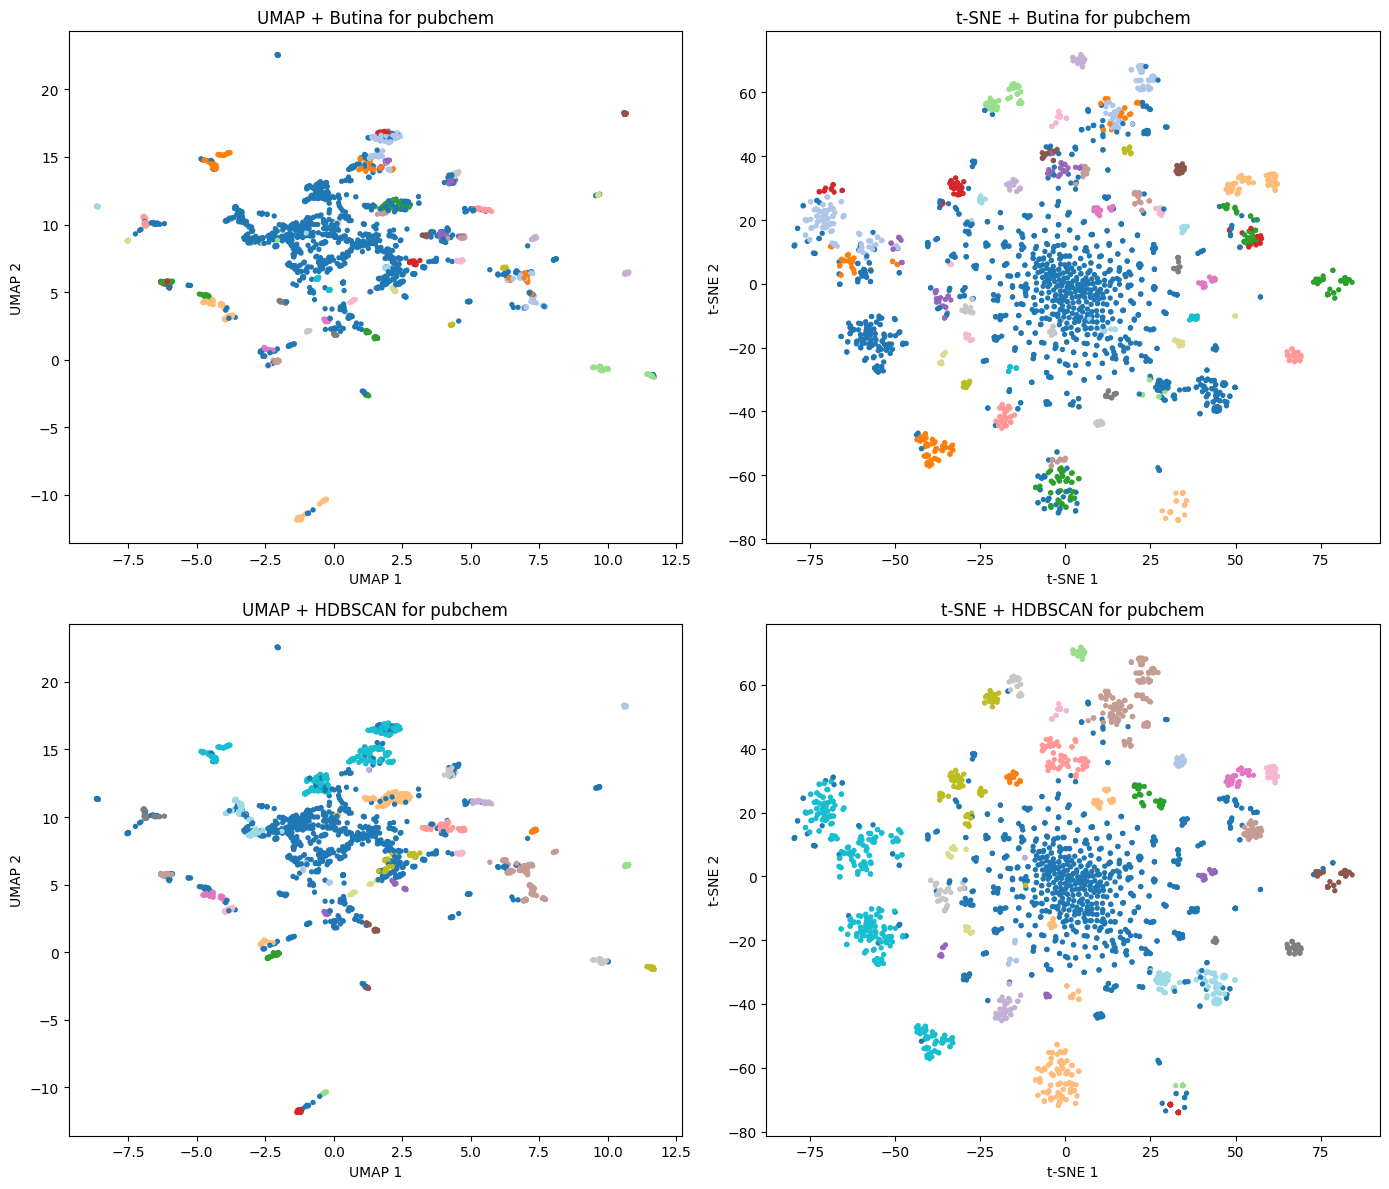

In [ ]:
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.scatter(umap_embedding_pubchem[:, 0], umap_embedding_pubchem[:, 1], c=butina_labels_pubchem, cmap="tab20", s=8)
plt.title("UMAP + Butina for pubchem")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.subplot(2, 2, 2)
plt.scatter(tsne_embedding_pubchem[:, 0], tsne_embedding_pubchem[:, 1], c=butina_labels_pubchem, cmap="tab20", s=8)
plt.title("t-SNE + Butina for pubchem")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.subplot(2, 2, 3)
plt.scatter(umap_embedding_pubchem[:, 0], umap_embedding_pubchem[:, 1], c=hdbs_labels_pubchem, cmap="tab20", s=8)
plt.title("UMAP + HDBSCAN for pubchem")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.subplot(2, 2, 4)
plt.scatter(tsne_embedding_pubchem[:, 0], tsne_embedding_pubchem[:, 1], c=hdbs_labels_pubchem, cmap="tab20", s=8)
plt.title("t-SNE + HDBSCAN for pubchem")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()



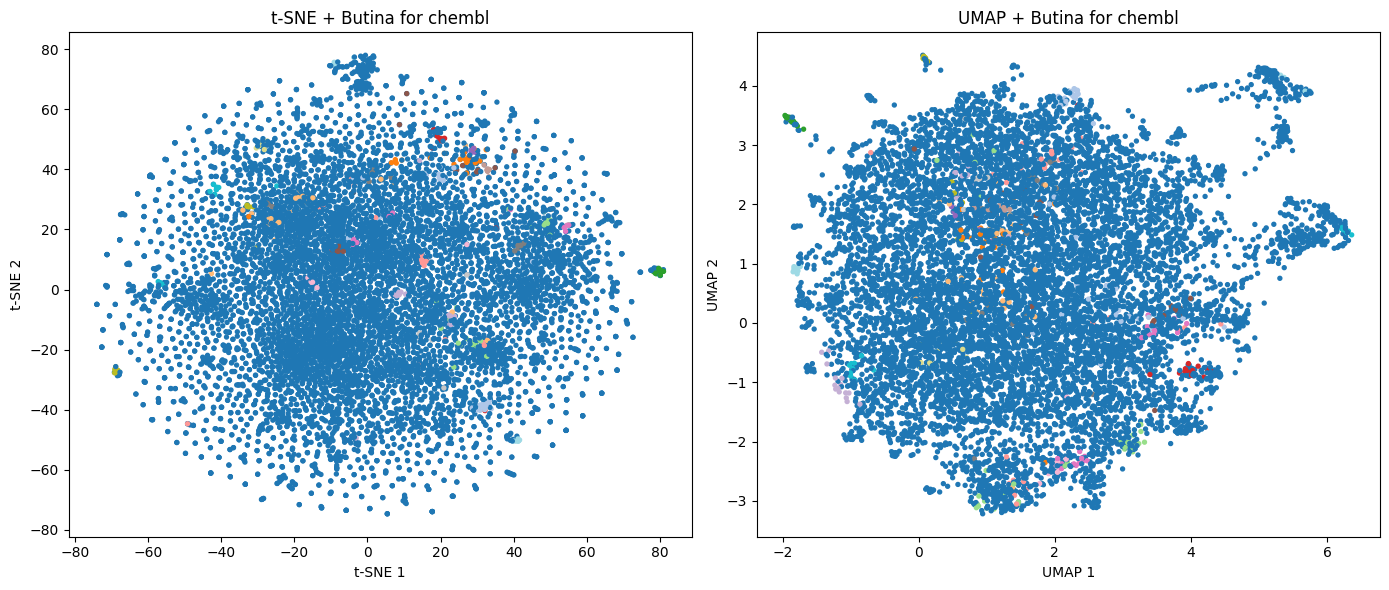

In [108]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(tsne_embedding_chembl[:, 0], tsne_embedding_chembl[:, 1], c=butina_labels_chembl, cmap="tab20", s=8)
plt.title("t-SNE + Butina for chembl")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.subplot(1, 2, 2)
plt.scatter(umap_embedding_chembl[:, 0], umap_embedding_chembl[:, 1], c=butina_labels_chembl, cmap="tab20", s=8)
plt.title("UMAP + Butina for chembl")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

Largest cluster chembl size: 30


[20:36:30] WARNING: not removing hydrogen atom without neighbors


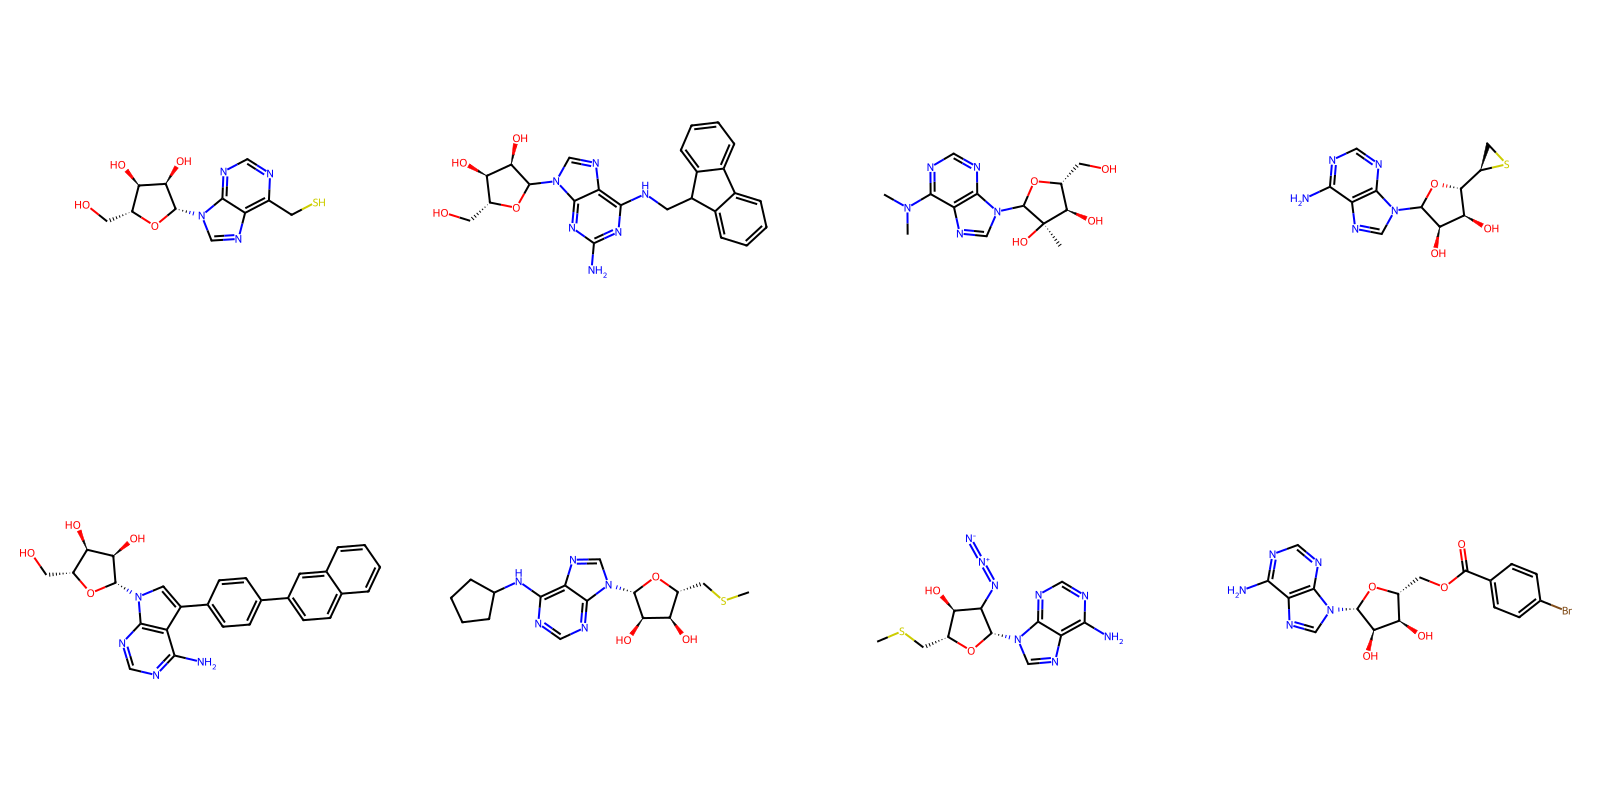

In [105]:
clusters_ordered_chembl = sorted(clusters_filtered_chembl, key=len, reverse=True)
clusters_ordered_pubchem = sorted(clusters_filtered_pubchem, key=len, reverse=True)

largest_cluster_chembl = clusters_ordered_chembl[0]
largest_cluster_pubchem = clusters_ordered_pubchem[0]

largest_cluster_chembl_mols = [Chem.MolFromSmiles(chembl_df_cleaned.iloc[idx]["smiles"]) for idx in largest_cluster_chembl]
largest_cluster_pubchem_mols = [Chem.MolFromSmiles(pubchem_df.iloc[idx]["smiles"]) for idx in largest_cluster_pubchem]

# Visualize the largest clusters
print("Largest cluster chembl size:", len(largest_cluster_chembl))
Draw.MolsToGridImage(largest_cluster_chembl_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

Largest cluster pubchem size: 125


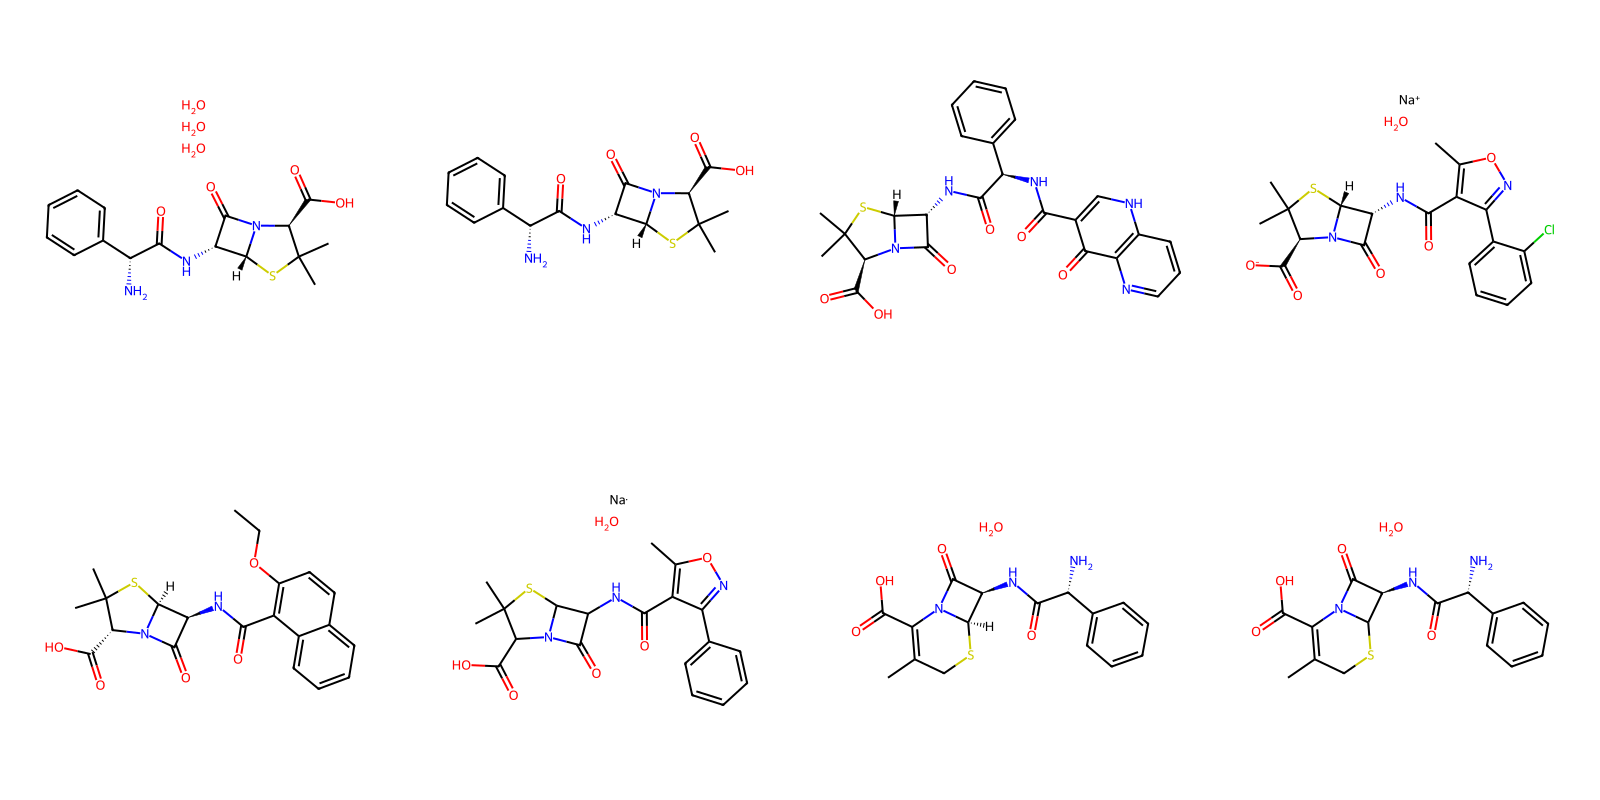

In [104]:
# Visualize the largest clusters
print("Largest cluster pubchem size:", len(largest_cluster_pubchem))
Draw.MolsToGridImage(largest_cluster_pubchem_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

Second largest cluster chembl size: 28


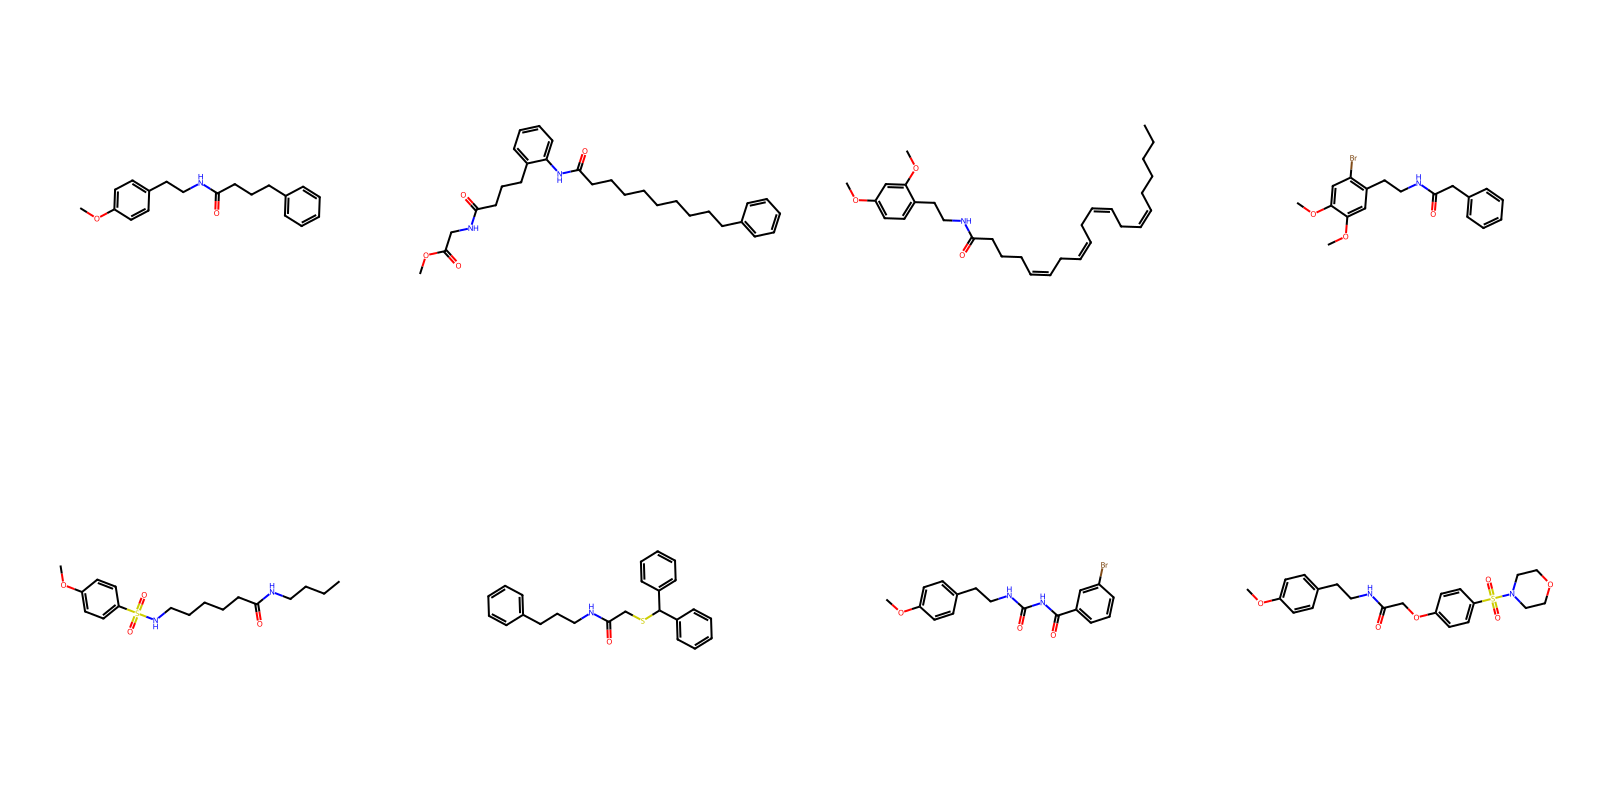

In [102]:
#Visualize second largest cluster
sec_largest_cluster_chembl = clusters_ordered_chembl[1]
sec_largest_cluster_pubchem = clusters_ordered_pubchem[1]

sec_largest_cluster_chembl_mols = [Chem.MolFromSmiles(chembl_df_cleaned.iloc[idx]["smiles"]) for idx in sec_largest_cluster_chembl]
sec_largest_cluster_pubchem_mols = [Chem.MolFromSmiles(pubchem_df.iloc[idx]["smiles"]) for idx in sec_largest_cluster_pubchem]

print("Second largest cluster chembl size:", len(sec_largest_cluster_chembl))
Draw.MolsToGridImage(sec_largest_cluster_chembl_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

Second largest cluster pubchem size: 109


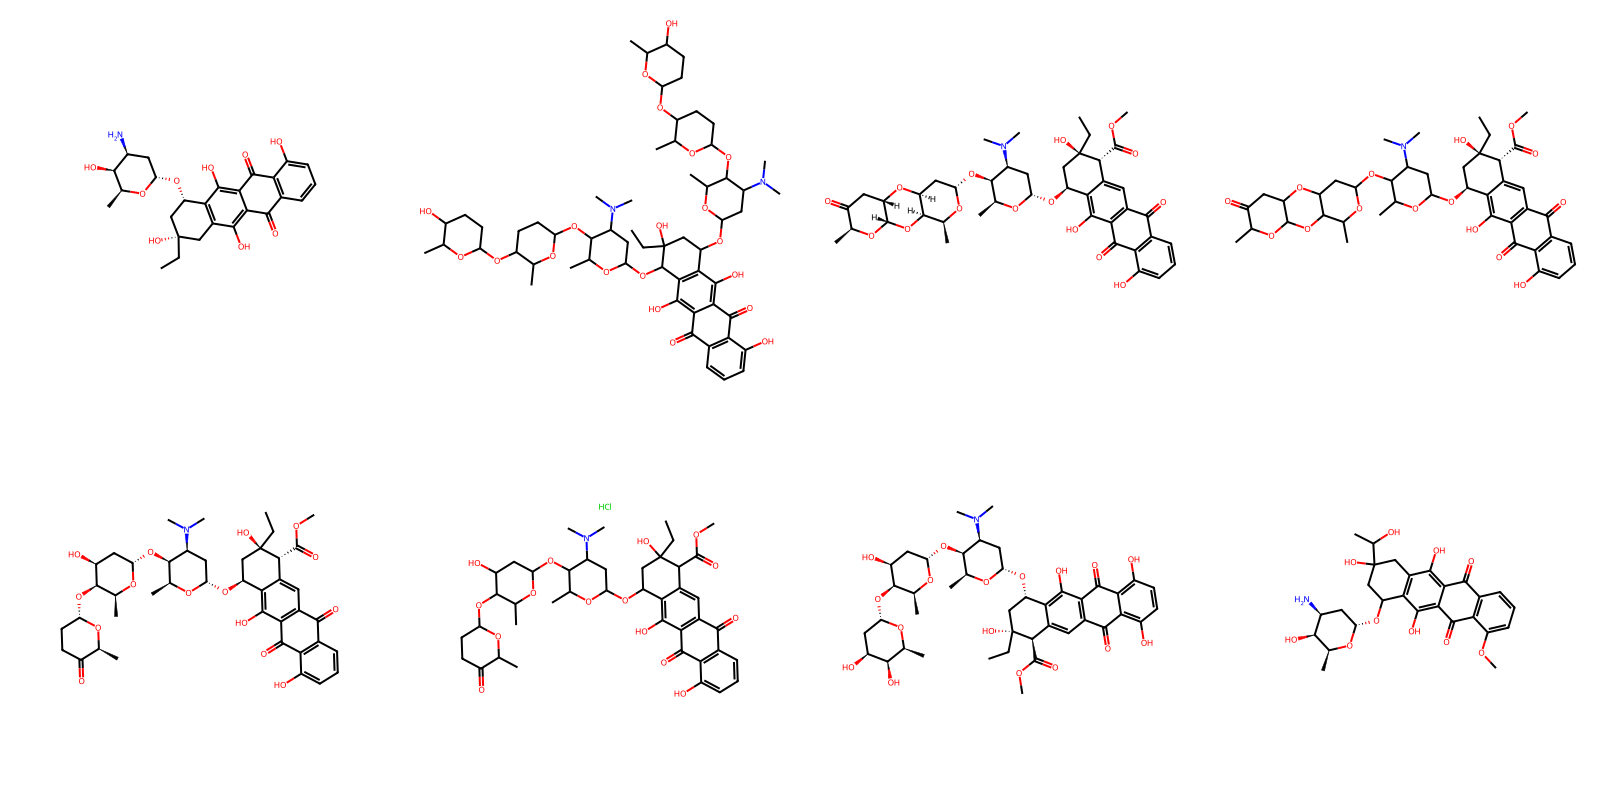

In [101]:
print("Second largest cluster pubchem size:", len(sec_largest_cluster_pubchem)) 
Draw.MolsToGridImage(sec_largest_cluster_pubchem_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

Third largest cluster chembl size: 26


[20:37:07] WARNING: not removing hydrogen atom without neighbors
[20:37:07] WARNING: not removing hydrogen atom without neighbors
[20:37:07] WARNING: not removing hydrogen atom without neighbors


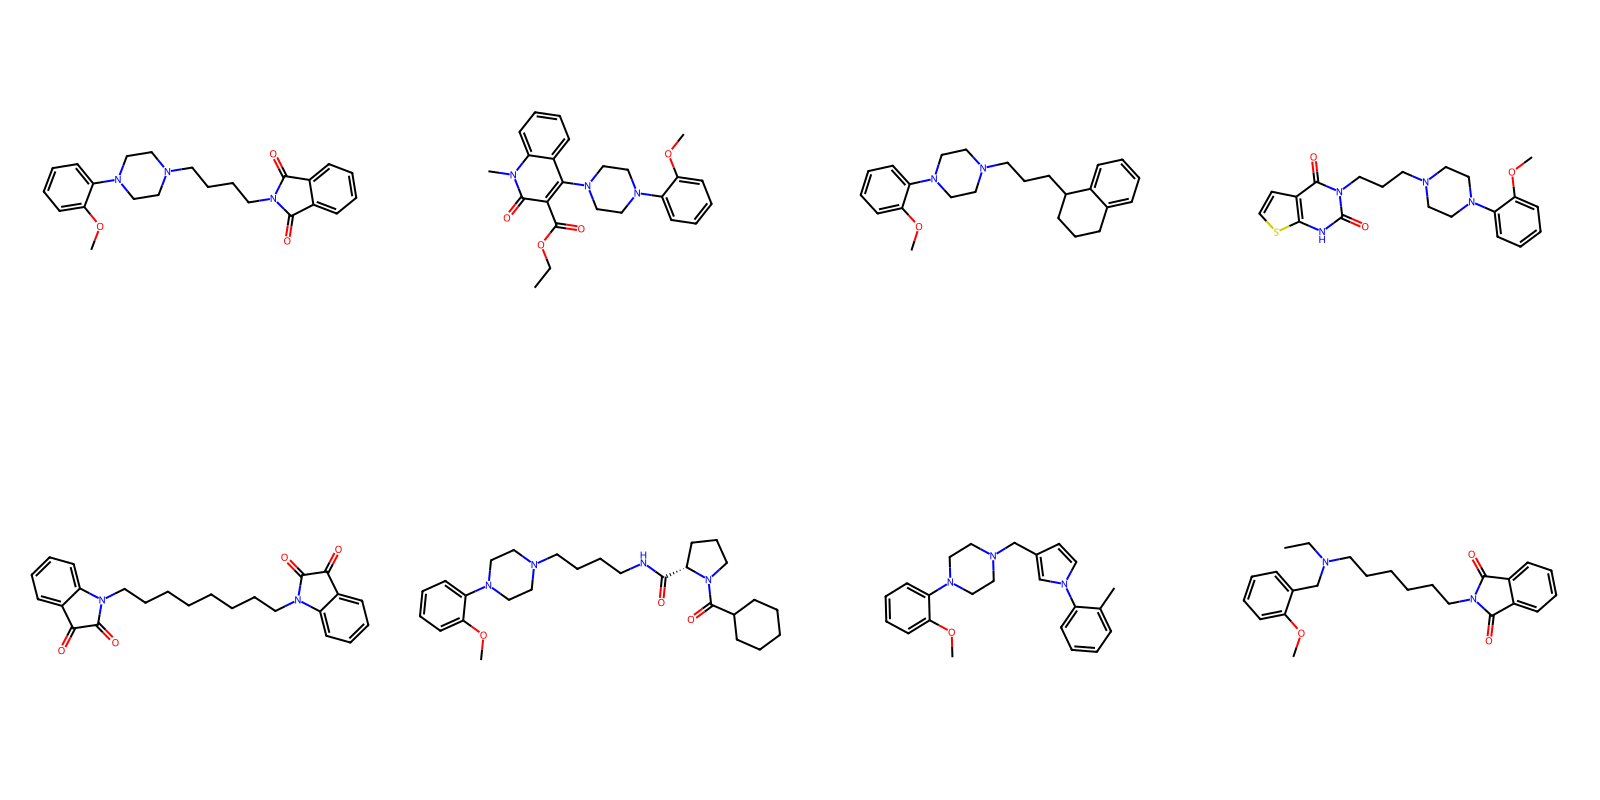

In [106]:
#Visualize third largest cluster
third_largest_cluster_chembl = clusters_ordered_chembl[2]
third_largest_cluster_pubchem = clusters_ordered_pubchem[2]

third_largest_cluster_chembl_mols = [Chem.MolFromSmiles(chembl_df_cleaned.iloc[idx]["smiles"]) for idx in third_largest_cluster_chembl]
third_largest_cluster_pubchem_mols = [Chem.MolFromSmiles(pubchem_df.iloc[idx]["smiles"]) for idx in third_largest_cluster_pubchem]

print("Third largest cluster chembl size:", len(third_largest_cluster_chembl))
Draw.MolsToGridImage(third_largest_cluster_chembl_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

Third largest cluster pubchem size: 102


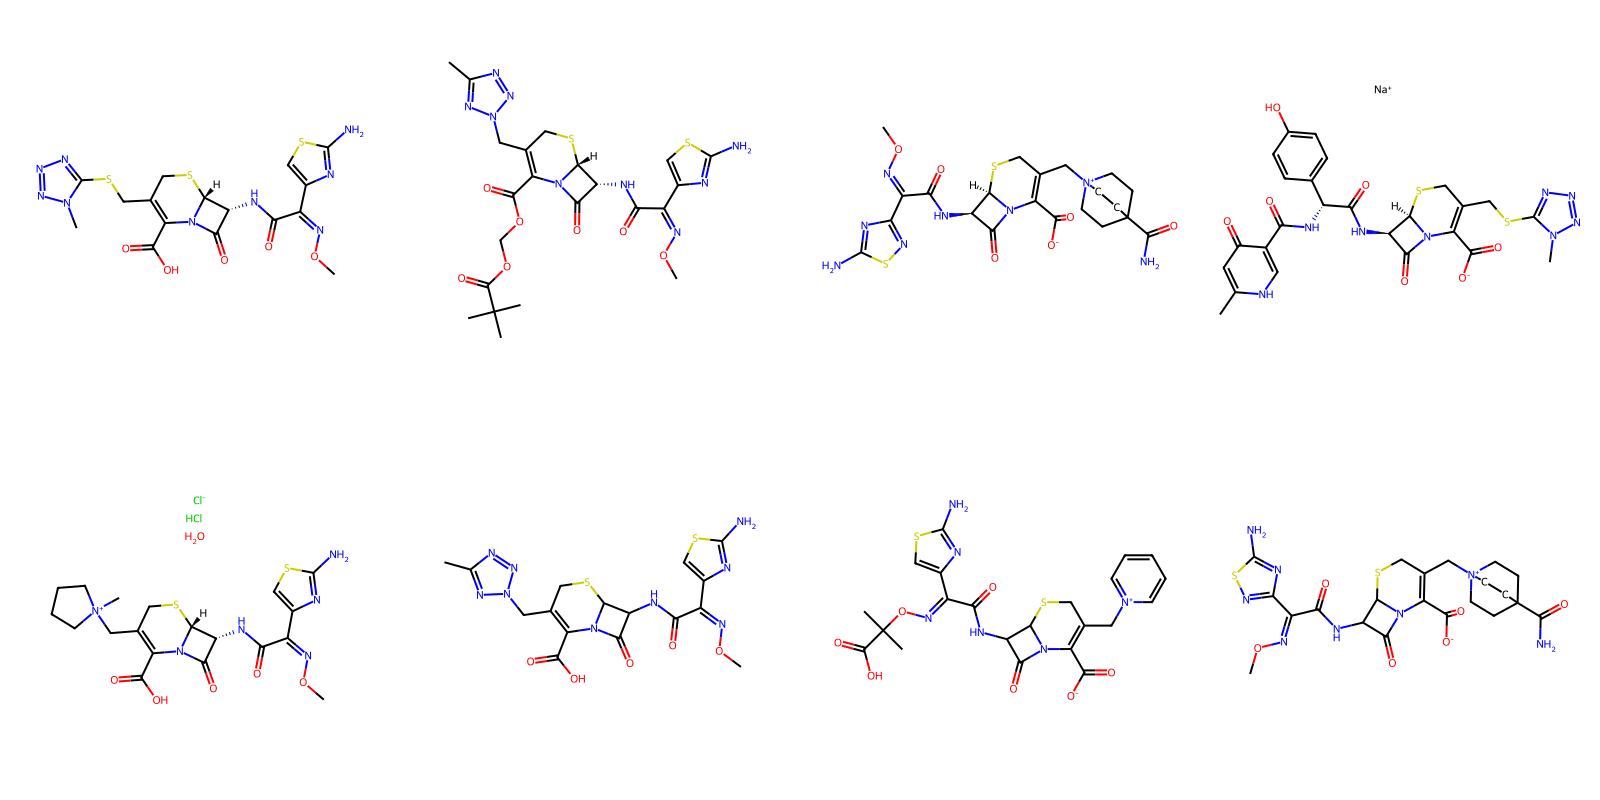

In [107]:
print("Third largest cluster pubchem size:", len(third_largest_cluster_pubchem))
Draw.MolsToGridImage(third_largest_cluster_pubchem_mols[0:8], molsPerRow=4, subImgSize=(400, 400))

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?


1. Well the big difference is the size of the data sets. ChemBL has a much more complex chemical space due to more entries. It is also more diverse as the pubchem is based on antibiotics.
2. The density based methods can detect noise which worked well in this notebook as we had to limit the cluster size with Butina (simmilarity) Actually density based methods did not work that well.
3. I did not change parameters really, especially for the HDBSCAN  with chembl as it did not compute even
4. In this approach, t-SNE gave a clearer seperation compared to UMAP. But t-SNE a bit artificial.
5. t-SNE and Butina
6. I had a lot of issues with runtime to the point where I couldnt even do the chembl HDBSCAN. The approach with only looking at clusters with more than 10 already improves it as it was done in the snippet 
7. Well I see a lot of heterocyclic and aromatic rings in the structures, which are common for drugs. Also in largest cluster a lot of cyclobutane rings which are also usually found in antibiotics molecules